In [ ]:
# ==================== Setup Environment & Clone Repository ====================
# Clone Shoebill repository
!git clone https://github.com/KJ-Liao/Shoebill.git
%cd Shoebill

# Install Python dependencies
!pip install -q \
    xgboost==3.0.2 \
    shap==0.46.0 \
    biopython \
    pandas \
    numpy \
    matplotlib \
    seaborn \
    joblib \

# Import required libraries
import pandas as pd
import numpy as np
import shap

import os
import re
import requests
from pathlib import Path
from bs4 import BeautifulSoup
from urllib.parse import urljoin

import glob
from IPython.display import display, Image

# ==================== Upload & Standardize File Names ====================
print("\nPlease complete the following steps:")
print("1. Predict your protein structure using AlphaFold2 or ColabFold")
print("   Recommended notebook:")
print("   https://colab.research.google.com/github/sokrypton/ColabFold/blob/main/AlphaFold2.ipynb")
print("2. Download the AlphaFold output ZIP file")
print("3. Save your sequence as TE_Sequence.fasta (single sequence)")
print("4. Upload the FASTA file and the AlphaFold ZIP file\n")

# Import required libraries
from google.colab import files

# --------------------------------------------------
# Step 1: Upload FASTA sequence
# --------------------------------------------------
print("=== Upload & standardize files for Shoebill ===")
print("Step 1: Upload your sequence file (TE_Sequence.fasta)")

# Upload FASTA sequence
uploaded_fasta = files.upload()

fasta_files = [f for f in uploaded_fasta if f.lower().endswith((".fasta", ".fa", ".fna"))]
if not fasta_files:
    raise FileNotFoundError("No FASTA file detected. Please upload a valid FASTA file.")

# Move to Shoebill Example folder
fasta_path = fasta_files[0]
target_dir = "/content/Shoebill/Example"
!cp $fasta_path $target_dir/

# Extract sample name from FASTA header
with open(fasta_path, 'r') as f:
    header = f.readline().strip()
    if not header.startswith('>'):
        raise ValueError("FASTA header must start with '>'")
sample_name = header[1:].split()[0].strip()

# --------------------------------------------------
# Step 2: Upload AlphaFold ZIP results
# --------------------------------------------------
print("\nStep 2: Upload your AlphaFold result ZIP file")

# Upload AlphaFold ZIP file
uploaded_zip = files.upload()

zip_files = [f for f in uploaded_zip if f.lower().endswith(".zip")]
if not zip_files:
    raise FileNotFoundError("No ZIP file detected. Please upload the AlphaFold output ZIP.")

# Remove common suffix patterns
original_zip = zip_files[0]
old_prefix = re.sub(r'(\.result)?(\.results)?\.zip$', '', original_zip, flags=re.IGNORECASE).strip()
old_prefix = re.sub(r'[_-]?result[s]?$', '', old_prefix, flags=re.IGNORECASE).strip()

# Standardize ZIP name
standard_zip = f"{sample_name}.zip"
!mv -f "{original_zip}" "{standard_zip}" 2>/dev/null || echo "Overwriting existing zip..."

# Extract, rename prefix, move to Example/AF_Result
output_dir = "Example/AF_Result"
!mkdir -p "{output_dir}"

temp_dir = "temp_af_extract"
!mkdir -p "{temp_dir}"
!unzip -o -q "{standard_zip}" -d "{temp_dir}"

# Rename files & folders to use sample_name
for root, dirs, files in os.walk(temp_dir, topdown=False):
    for file in files:
        old_path = os.path.join(root, file)
        new_file = file.replace(original_zip.split('.')[0], sample_name)
        new_path = os.path.join(root, new_file)
        if old_path != new_path:
            os.rename(old_path, new_path)

    for dir_name in dirs[:]:
        old_dir = os.path.join(root, dir_name)
        new_dir_name = dir_name.replace(original_zip.split('.')[0], sample_name)
        new_dir = os.path.join(root, new_dir_name)
        if old_dir != new_dir:
            os.rename(old_dir, new_dir)

# Move to Shoebill Example folder
!rsync -a --remove-source-files "{temp_dir}/" "{output_dir}/"
!rm -rf "{temp_dir}"

print("Files standardized and moved to Example/AF_Result/")

Cloning into 'Shoebill'...
remote: Enumerating objects: 257, done.
remote: Counting objects: 100% (71/71), done.
remote: Compressing objects: 100% (69/69), done.
remote: Total 257 (delta 39), reused 0 (delta 0), pack-reused 186 (from 1)
Receiving objects: 100% (257/257), 30.20 MiB | 17.87 MiB/s, done.
Resolving deltas: 100% (123/123), done.
/content/Shoebill
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.9/543.9 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 77.5 MB/s eta 0:00:00

Please complete the following steps:
1. Predict your protein structure using AlphaFold2 or ColabFold
   Recommended notebook:
   https://colab.research.google.com/github/sokrypton/ColabFold/blob/main/AlphaFold2.ipynb
2. Download the AlphaFold output ZIP file
3. Save your sequence as TE_Sequence.fasta (single sequence)
4. Upload the FASTA file and the AlphaFold ZIP file

=== Upload & standardize fi

Saving TE_Sequence.fasta to TE_Sequence.fasta

Step 2: Upload your AlphaFold result ZIP file


Saving 2OB4_2cdee.result.zip to 2OB4_2cdee.result.zip
Files standardized and moved to Example/AF_Result/


In [ ]:
# ==================== Install External Dependencies ====================
# 0. Create directory for external binaries
!mkdir -p bin

# --------------------------------------------------
# 1. Install EDTSurf
# --------------------------------------------------
!wget -q https://aideepmed.com/EDTSurf/EDTSurf.zip -O EDTSurf.zip
!unzip -o EDTSurf.zip -d bin/
!chmod +x bin/EDTSurf
print("EDTSurf installed.")

# --------------------------------------------------
# 2. Install DSSP (mkdssp)
# --------------------------------------------------
# Install compilation dependencies
!apt-get install -y autoconf automake libtool make g++ zlib1g-dev libbz2-dev

# Clone DSSP source
!git clone https://github.com/cmbi/dssp.git
%cd dssp

# Compile DSSP
#!git tag
#!git checkout 3.1.4
!sudo apt update
!sudo apt install libboost-all-dev
!autoreconf -i
!./configure
!make

# Move mkdssp to Shoebill binary folder
!cp mkdssp /content/Shoebill/bin/
!chmod +x /content/Shoebill/bin/mkdssp
%cd ..
print("DSSP installed.")

# --------------------------------------------------
# 3. Install Zernike3D (MakeShape & Shape2Zernike)
# --------------------------------------------------
# Install compilation dependencies
!apt-get update -qq
!apt-get install -y cmake g++ libeigen3-dev

# Clone Zernike3D source
!git clone https://github.com/jerhoud/zernike3d.git
%cd zernike3d

# Compile Zernike3D
!mkdir -p build
!cmake -S src -B build
!cmake --build build --parallel $(nproc)
!mkdir -p ../bin
!cmake --install build --prefix ../bin

# Move MakeShape & Shape2Zernike to Shoebill binary folder
!chmod +x ../bin/bin/MakeShape ../bin/bin/Shape2Zernike
!mv ../bin/bin/MakeShape ../bin/
!mv ../bin/bin/Shape2Zernike ../bin/
%cd ..
print("Zernike3D installed.")

# --------------------------------------------------
# 4. Install KORP
# --------------------------------------------------
# Step 1: Searching for KORP Linux64 download page
base_url = "https://chaconlab.org"
main_page_url = f"{base_url}/modeling/korp/down-korp"

response = requests.get(main_page_url, timeout=15)
response.raise_for_status()

soup = BeautifulSoup(response.text, 'html.parser')
item_link = None
for a in soup.find_all('a'):
    text = a.get_text(strip=True)
    if "KORP Linux64" in text or "Linux64" in text:
        href = a.get('href')
        if href and '/item/korp-linux' in href:
            item_link = urljoin(base_url, href)
            print("Found KORP item page:", item_link)
            break

# Fallback link if page structure changes
if not item_link:
    print("KORP Linux64 not found. Please visit 'https://chaconlab.org/modeling/korp/down-korp'.")
    item_link = f"{base_url}/modeling/korp/down-korp/item/korp-linux"

# Step 2: Searching for KORP Linux64 download link
response2 = requests.get(item_link, timeout=15)
response2.raise_for_status()

soup2 = BeautifulSoup(response2.text, 'html.parser')
download_url = None
for a in soup2.find_all('a'):
    text = a.get_text(strip=True).lower()
    if "download" in text or "[download]" in text:
        href = a.get('href')
        if href and 'task=callelement' in href and 'args[0]' in href:
            download_url = urljoin(base_url, href)
            break

# Fallback link if page structure changes
if not download_url:
    print("KORP Linux64 not found. Please visit 'https://chaconlab.org/modeling/korp/down-korp'.")
    download_url = f"{base_url}/component/zoo/?task=callelement&format=raw&item_id=36&element=f85c494b-2b32-4109-b8c1-083cca2b7db6&method=download&args[0]=7c9b420071b6f9aff446dfe268c05673"

# Step 3: Download & extract KORP Linux64
if download_url:
    filename = "Korp6Dv1.txz"

    r = requests.get(download_url, stream=True, timeout=30)
    r.raise_for_status()

    with open(filename, 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)

    # Extract package
    !tar -xJf Korp6Dv1.txz -C /content/Shoebill/bin/
    !chmod +x /content/Shoebill/bin/Korp6Dv1/bin/korpe
    !mv /content/Shoebill/bin/Korp6Dv1/korp6Dv1.bin /content/Shoebill/bin/
    !mv /content/Shoebill/bin/Korp6Dv1/bin/korpe /content/Shoebill/bin/
    print("KORP installed.")
else:
    print("Failed to find KORP download link. Please visit 'https://chaconlab.org/modeling/korp/down-korp'.")

Archive:  EDTSurf.zip
  inflating: bin/CommonPara.h        
  inflating: bin/ParsePDB.h          
  inflating: bin/Makefile            
  inflating: bin/ParsePDB.cpp        
  inflating: bin/ProteinSurface.cpp  
  inflating: bin/ProteinSurface.h    
  inflating: bin/EDTSurf.cpp         
  inflating: bin/EDTSurf             
EDTSurf installed.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
autoconf is already the newest version (2.71-2).
autoconf set to manually installed.
automake is already the newest version (1:1.16.5-1.3).
automake set to manually installed.
g++ is already the newest version (4:11.2.0-1ubuntu1).
g++ set to manually installed.
libbz2-dev is already the newest version (1.0.8-5build1).
libbz2-dev set to manually installed.
make is already the newest version (4.3-4.1build1).
make set to manually installed.
zlib1g-dev is already the newest version (1:1.2.11.dfsg-2ubuntu9.2).
zlib1g-dev set to manually installed.
Suggested

In [ ]:
# ==================== Preprocess AlphaFold results & extract features ====================
print("=== Preprocessing AlphaFold results ===")
!python Example/AF_Preprocessing.py \
    Example/TE_Sequence.fasta \
    Example/AF_Result \
    Example/Processed_AF_Result

print("\n=== Extracting 830 features ===")
# Minor fix for DSSP command compatibility
!sed -i 's|--output-format=dssp||g' Example/TE_feature.py
!sed -i 's|run_cmd(\[mkdssp, pdb001, ""\])|run_cmd([mkdssp, pdb001])|g' Example/TE_feature.py

!python Example/TE_feature.py \
    Example/TE_Sequence.fasta \
    Example/Processed_AF_Result \
    Example/TE_feature.csv \
    --bin /content/Shoebill/bin

print("\nFeature extraction completed!")

=== Preprocessing AlphaFold results ===

=== Extracting 830 features ===
[OK] 2OB4 (830 features)
[DONE] Saved features to Example/TE_feature.csv

Feature extraction completed!


In [ ]:
# ==================== Run crystallization propensity prediction ====================
print("=== Running Shoebill prediction ===")
print("Using default threshold 0.420\n")

!python shoebill_predict.py \
  --model shoebill_model \
  --input Example/TE_feature.csv \
  --output preds.csv \
  --threshold 0.420

print("\nPrediction completed. Results:")
!cat preds.csv

print("\n=== Interpretation guide ===")
print("- pred_proba: Probability of successful crystallization (higher = more likely)")
print("- pred_label: 1 = predicted to crystallize easily, 0 = unlikely")

=== Running Shoebill prediction ===
Using default threshold 0.420

[OK] Predictions saved: preds.csv (threshold=0.420)

Prediction completed. Results:
ID,pred_proba,pred_label
2OB4,0.65922916,1

=== Interpretation guide ===
- pred_proba: Probability of successful crystallization (higher = more likely)
- pred_label: 1 = predicted to crystallize easily, 0 = unlikely


[OK] Generated 1 SHAP waterfall plots in: /content/Shoebill/shap_plots

SHAP plots saved in shap_plots/ folder
Red = increases predicted probability, Blue = decreases
A detailed description of all features and their computational definitions is 
provided in 'https://github.com/KJ-Liao/Shoebill/tree/main/Supplementary_Files'.

=== Pred_prob_2OB4.png ===


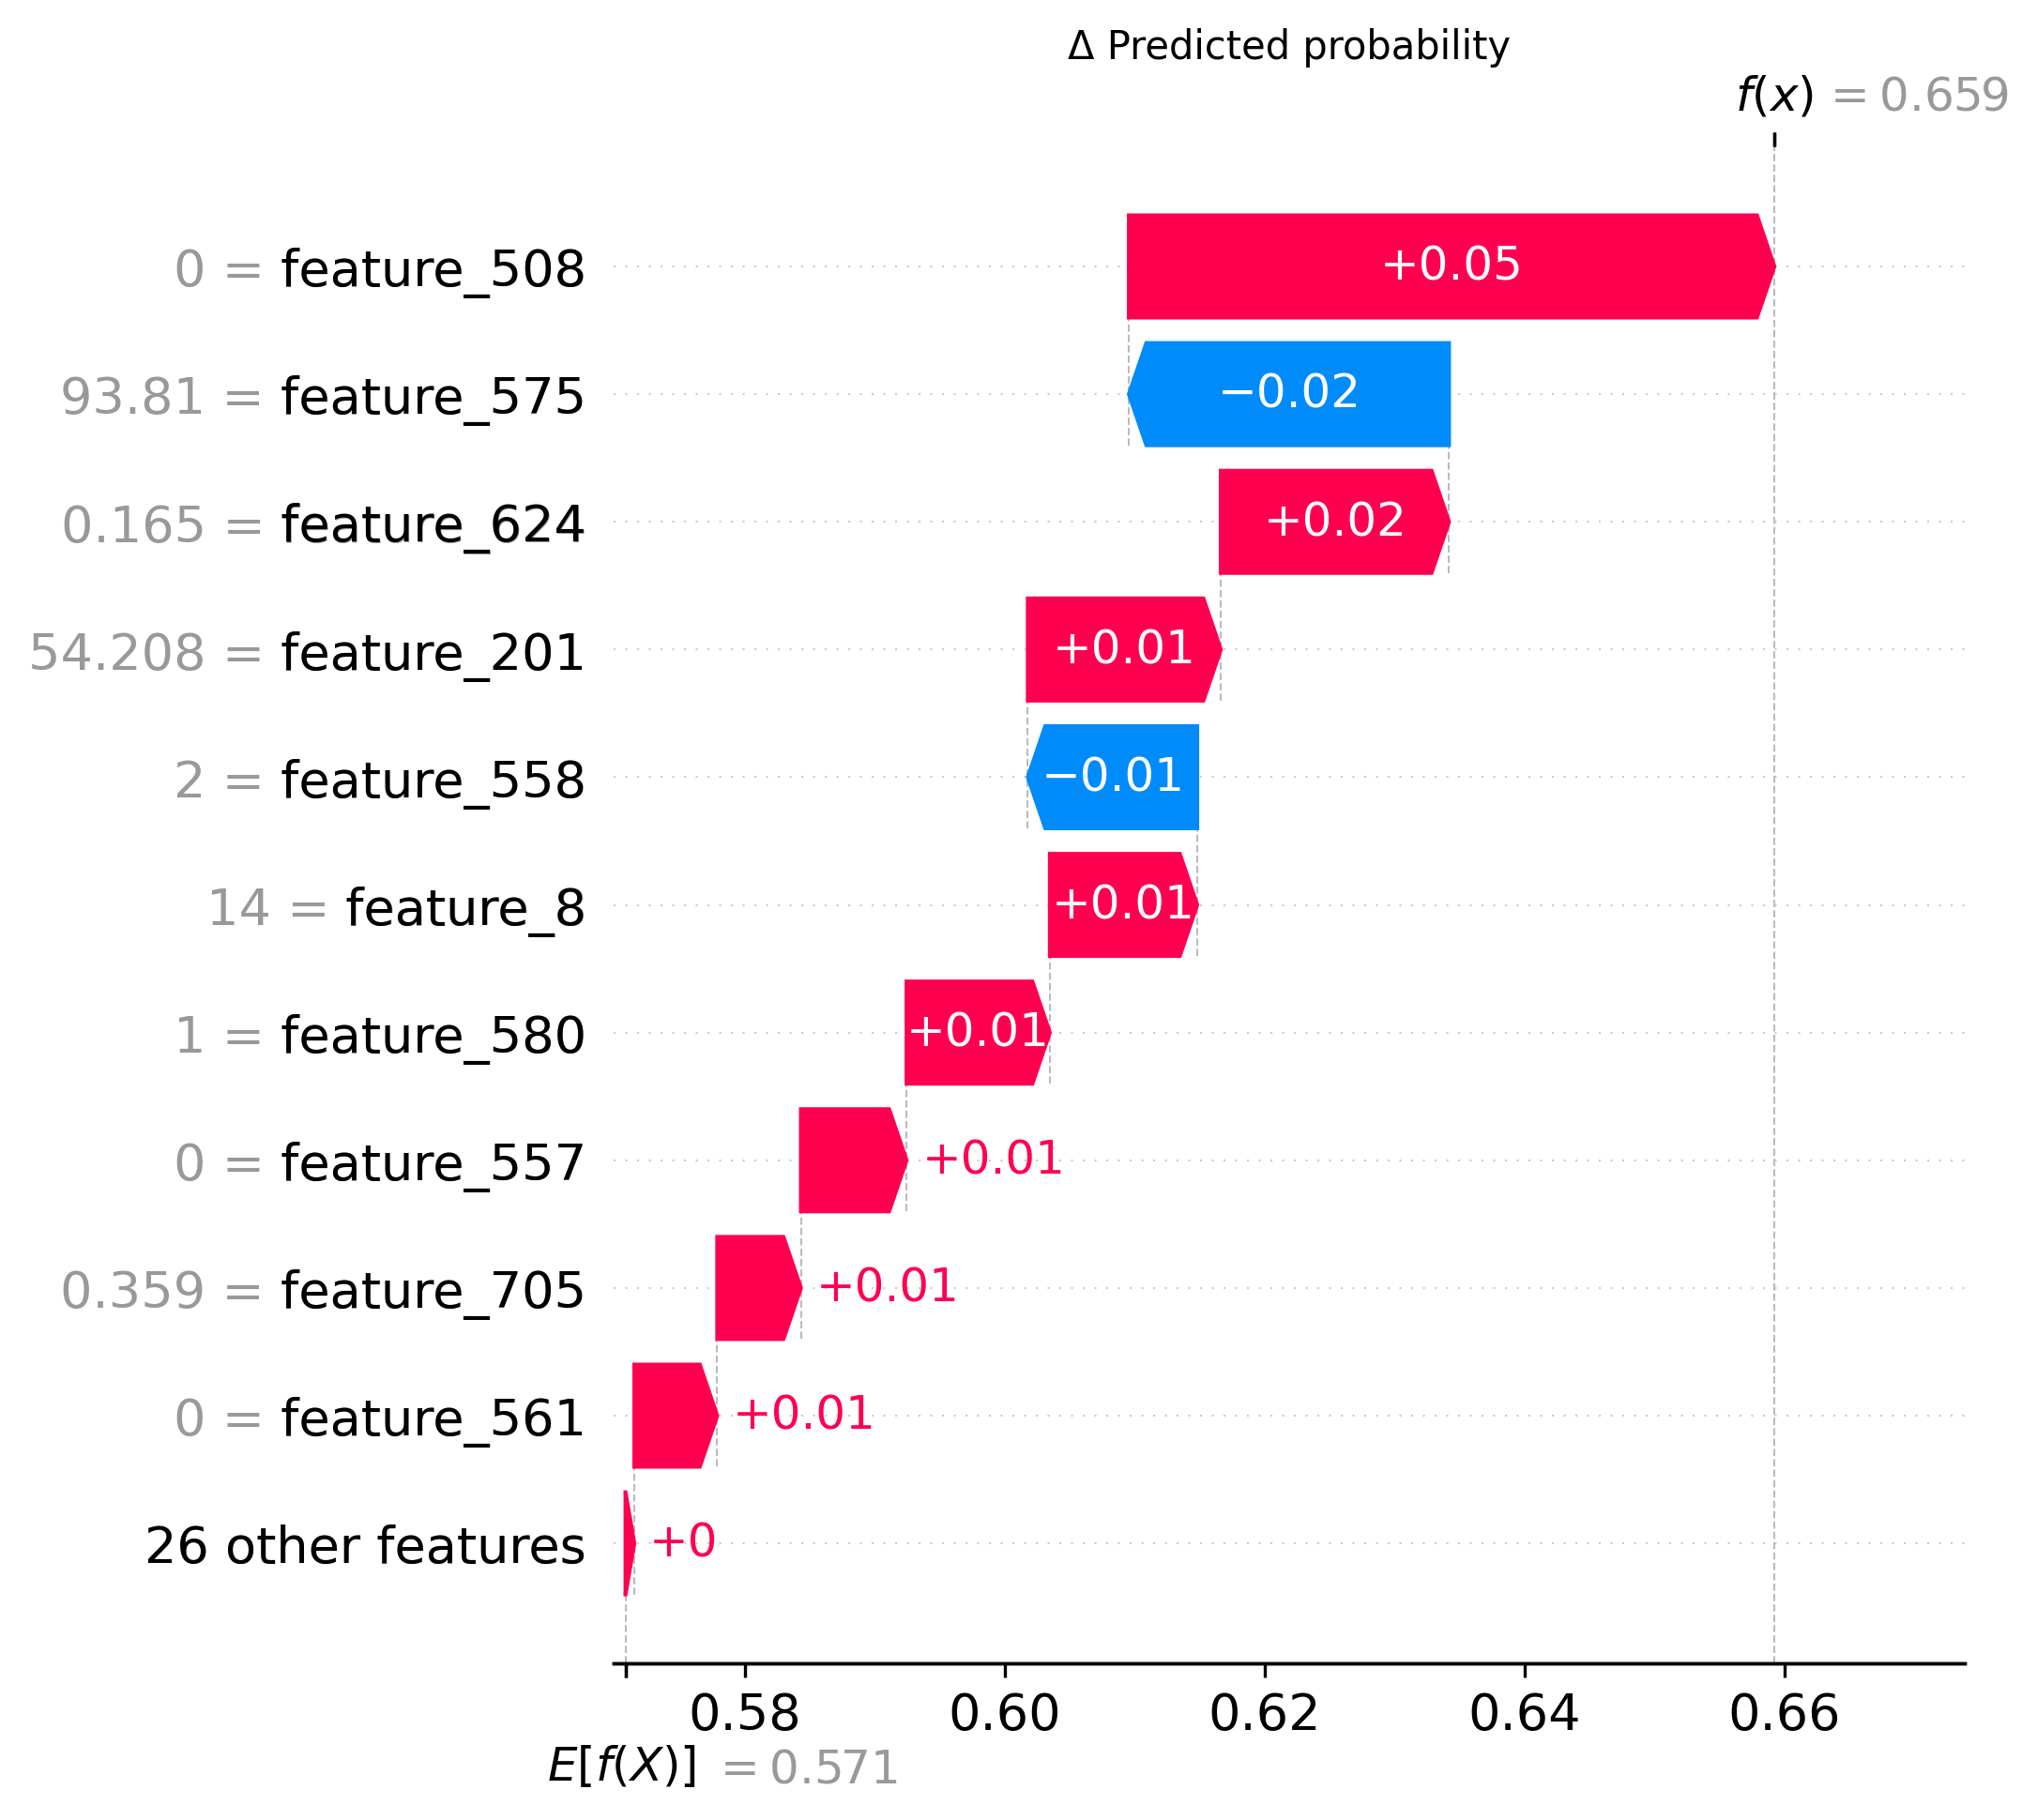

In [ ]:
# ==================== SHAP Interpretability Analysis ====================
# Minor layout adjustment for better PDF display
!sed -i 's/plt.tight_layout()/plt.subplots_adjust(left=0.3)/' shoebill_shap_waterfall.py

# Create directory for SHAP analysis
!mkdir -p shap_plots

!python shoebill_shap_waterfall.py \
  --model shoebill_model \
  --input Example/TE_feature.csv \
  --train-data Example/TR_feature_3000.csv \
  --output-dir shap_plots \
  --max-display 11

print("\nSHAP plots saved in shap_plots/ folder")
print("Red = increases predicted probability, Blue = decreases")
print("A detailed description of all features and their computational definitions is ")
print("provided in 'https://github.com/KJ-Liao/Shoebill/tree/main/Supplementary_Files'.")

# SHAP analysis display
pdf_folder = "shap_plots"
png_files = sorted(glob.glob(f"{pdf_folder}/*.png"))

for png_path in png_files:
    print(f"\n=== {os.path.basename(png_path)} ===")
    display(Image(filename=png_path, width=700))